# Monte Carlo Simulation for Femeli Stock Price

In this project, we simulate the price of the **Femeli** stock over the **next 30 trading days** using the Monte Carlo method. The model is **Geometric Brownian Motion (GBM)**, where each day's price is built from the previous day's price:

$$S_t = S_{t-1} \cdot e^{\left(\mu - \frac{1}{2}\sigma^2\right) + \sigma Z}$$

- $\mu$: mean of daily log returns
- $\sigma$: standard deviation of daily log returns
- $Z$: random number drawn from the standard normal distribution

In [1]:
import numpy as np 
import pandas as pd 
import finpy_tse as fpy
import matplotlib.pyplot as plt 
from scipy.stats import norm

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## 1. Data

Adjusted closing prices of Femeli from 1400-01-01 to 1405-07-14 are downloaded using the finpy-tse library. Adjusted prices are used so that the effects of capital increases and dividends are removed from the price history.

In [2]:
df = fpy.Get_Price_History(stock = 'فملی' , start_date = '1400-01-01' , end_date = '1405-07-14' , adjust_price = True )['Adj Close']
S = df.to_frame('Femeli')

In [3]:
S.to_csv('femeli_prices.csv')

## 2. Log Returns

The daily log return is the natural log of today's price divided by yesterday's price. The price chart and the log return chart are shown below.

In [4]:
log_returns = np.log( S/S.shift(1) )

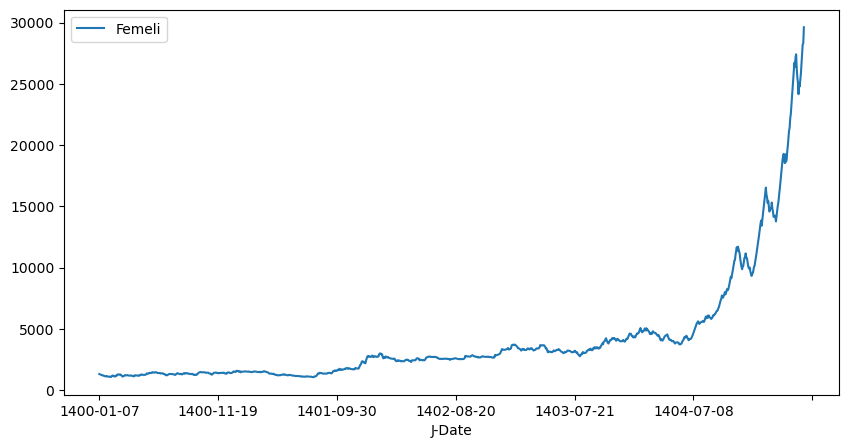

In [5]:
ax1 = S.plot(figsize = (10,5))

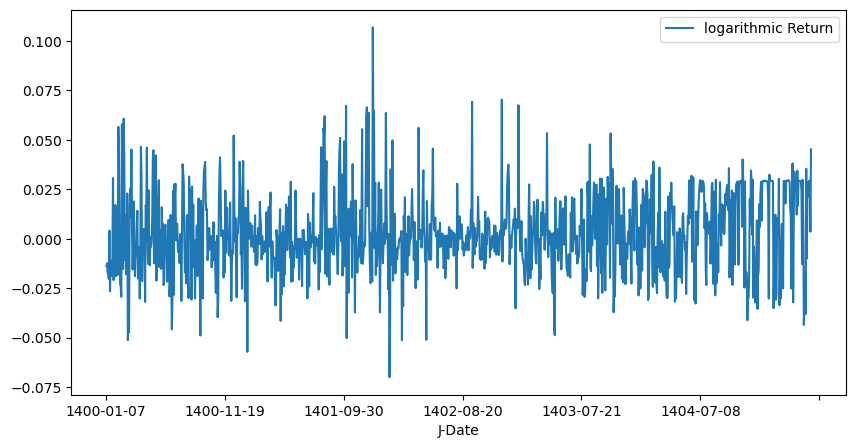

In [6]:
ax2 = log_returns.plot(figsize = (10,5))
ax2.legend(['logarithmic Return'])

## 3. Model Parameters

From the historical returns, we compute the mean and standard deviation, then build the **drift**:

$$drift = \mu - \frac{1}{2}\sigma^2$$

Subtracting $\frac{1}{2}\sigma^2$ keeps the simulated average price consistent with the true expected value.

In [7]:
u = log_returns.mean()
var = log_returns.var()
std_dev = log_returns.std()

In [8]:
drift = ( u - 0.5 * var )

## 4. Simulation

- T = 31: the first row is today's price and the next 30 rows are the next 30 days.
- N = 1000: number of simulated price paths.
- np.random.seed(42): makes the results reproducible on every run.

First, we generate the matrix of random daily returns (31 rows × 1000 columns).

In [9]:
T = 31
N = 1000

In [10]:
np.random.seed(42)
daily_return = np.exp(drift.values + std_dev.values * norm.ppf(np.random.rand(T , N)))

In [11]:
S0 = S.iloc[-1,0]

In [12]:
prices = np.zeros_like(daily_return)
prices[0] = S0

Each day's price equals the previous day's price multiplied by that day's random return:

$$S_t = S_{t-1} \cdot R_t, \qquad R_t = e^{\left(\mu - \frac{1}{2}\sigma^2\right) + \sigma Z_t}$$

- $S_t$: simulated price on day $t$
- $R_t$: random daily return factor on day $t$
- $Z_t$: random draw from the standard normal distribution

This is repeated for $t = 1, 2, \dots, 30$, and it is done for all 1000 paths at the same time.

In [13]:
for t in range(1,T) :
    prices[t] = prices[t-1] * daily_return[t]


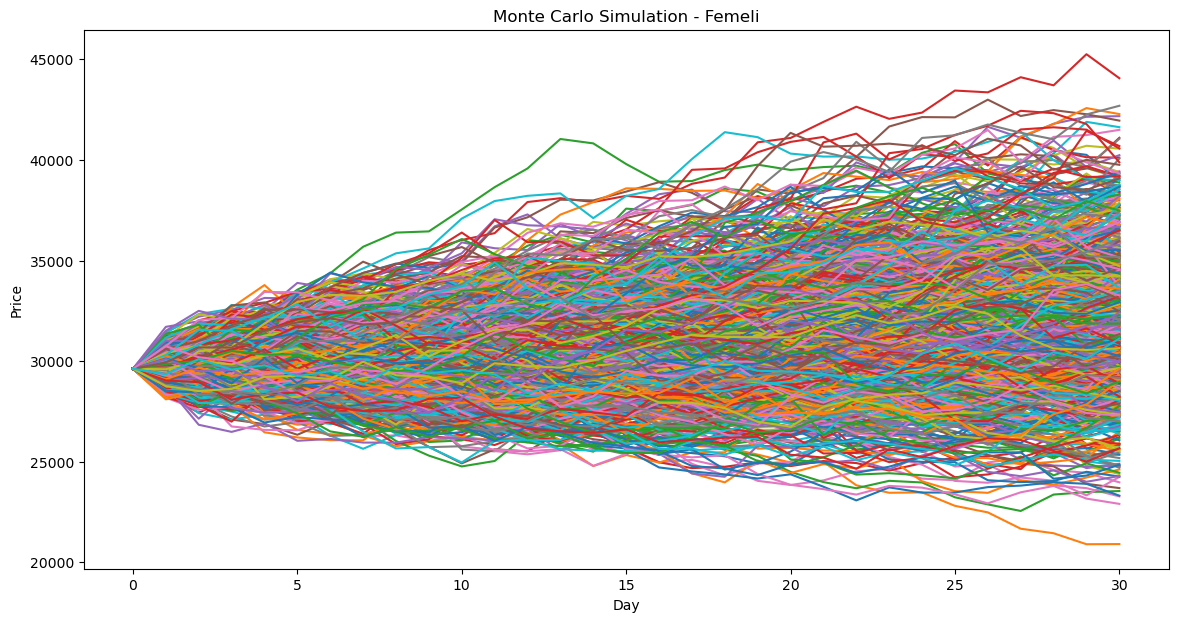

In [14]:
plt.figure(figsize=(14,7))
plt.plot(prices)
plt.title('Monte Carlo Simulation - Femeli')
plt.xlabel('Day')
plt.ylabel('Price')
plt.savefig('simulation_paths.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Results

The table below summarizes the day-30 prices across all 1000 simulations:

- **Mean / Median**: average and median of the final price
- **5% and 95%**: the range containing 90% of the simulated final prices
- **Expected Return %**: expected return relative to today's price
- **Loss Probability %**: percentage of paths where the final price is below today's price

In [15]:
final_prices = prices[-1]

summary = pd.DataFrame({
    'Mean': [int(final_prices.mean())],
    'Median': [int(np.median(final_prices))],
    '5% (Low)': [int(np.percentile(final_prices, 5))],
    '95% (High)': [int(np.percentile(final_prices, 95))],
    'Expected Return %': [(final_prices.mean() / prices[0, 0] - 1) * 100],
    'Loss Probability %': [(final_prices < prices[0, 0]).mean() * 100]
}, index=['Femeli'])

summary.round(2)

,Mean,Median,5% (Low),95% (High),Expected Return %,Loss Probability %
Femeli,32050,31947,26759,38224,8.21,25.1


Distribution of the final simulated price. The red line is today's price and the green line is the mean predicted price.

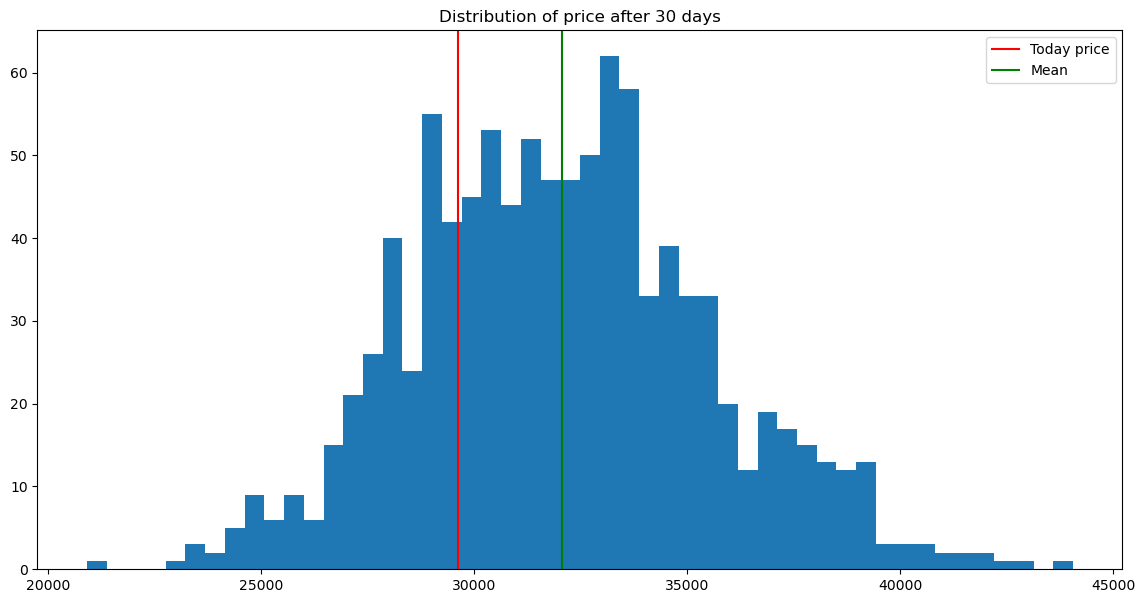

In [16]:
plt.figure(figsize=(14,7))
plt.hist(final_prices, bins=50)
plt.axvline(prices[0, 0], color='red', label='Today price')
plt.axvline(final_prices.mean(), color='green', label='Mean')
plt.legend()
plt.title('Distribution of price after 30 days')
plt.savefig('final_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.Analysis of the Results

**Central estimate.** The mean final price is about 32,050 and the median is 31,947. Compared with today's price (29,620), this means the model expects roughly an **8% gain** over 30 trading days. The mean is slightly higher than the median because price distributions under GBM are right-skewed: a few very high-price paths pull the average up.

**Range of outcomes.** In 90% of the simulations, the final price falls between about 26,750 (5th percentile) and 38,200 (95th percentile). Relative to today's price, that is roughly **-10% to +29%**. The range is not symmetric: the potential upside is larger than the potential downside, which is again a consequence of the multiplicative nature of the model.

**Risk of loss.** About **25% of the simulated paths** end below today's price, so the model assigns roughly a 75% probability to a gain and 25% to a loss over this horizon.

**How to read these numbers.** The positive expected return comes directly from the stock's historical drift (2021 to 2026), a period of high inflation and strong nominal growth. The model assumes this drift continues. If the stock's behavior changes, the real outcome can be very different. These results describe what would happen *if the past pattern repeats*, and they are best used to understand the **spread of possible outcomes**, not to predict one exact price.

## 7. Conclusion and Limitations

These results are a **possible scenario** based on the stock's past behavior, not a definitive forecast. Limitations of the model:

- It assumes returns are normally distributed and volatility is constant.
- The high nominal growth of recent years (driven by inflation) is built into the drift and may not repeat.
- Price limits, trading halts, and sudden market shocks are not modeled.
- 30 days here means 30 trading days, not calendar days.